In [ ]:
from scipy.stats import kendalltau
import numpy as np

# Rankings for each round (US1 to US12)
p7 = [1, 10, 2, 6, 4, 7, 11, 5, 3, 12, 8, 9]
p8 = [1, 10, 4, 6, 7, 9, 11, 2, 3, 12, 8, 5]
p9 = [2, 9, 3, 5, 6, 7, 11, 8, 4, 12, 10, 1]

# Function to convert Kendall's Tau similarity to distance
def kendall_tau_distance(a, b):
    tau, _ = kendalltau(a, b)
    return 1 - tau

# Compute pairwise distances
dist_p7_p8 = kendall_tau_distance(p7, p8)
dist_p7_p9 = kendall_tau_distance(p7, p9)
dist_p8_p9 = kendall_tau_distance(p8, p9)

# Compute average distances
avg_p7 = np.mean([dist_p7_p8, dist_p7_p9])
avg_p8 = np.mean([dist_p7_p8, dist_p8_p9])
avg_p9 = np.mean([dist_p7_p9, dist_p8_p9])

# Print results
print("Kendall's Tau Distances:")
print(f"P7 vs P8: {dist_p7_p8:.3f}")
print(f"P7 vs P9: {dist_p7_p9:.3f}")
print(f"P8 vs P9: {dist_p8_p9:.3f}\n")

print("Average Distance per Round:")
print(f"P7: {avg_p7:.3f}")
print(f"P8: {avg_p8:.3f}")
print(f"P9: {avg_p9:.3f}\n")

# Determine closest to others
distances = {'P7': avg_p7, 'P8': avg_p8, 'P9': avg_p9}
closest = min(distances, key=distances.get)
print(f"The round most aligned with the others is: {closest}")


Kendall's Tau Distances:
P7 vs P8: 0.303
P7 vs P9: 0.364
P8 vs P9: 0.364

Average Distance per Round:
P7: 0.333
P8: 0.333
P9: 0.364

The round most aligned with the others is: P7


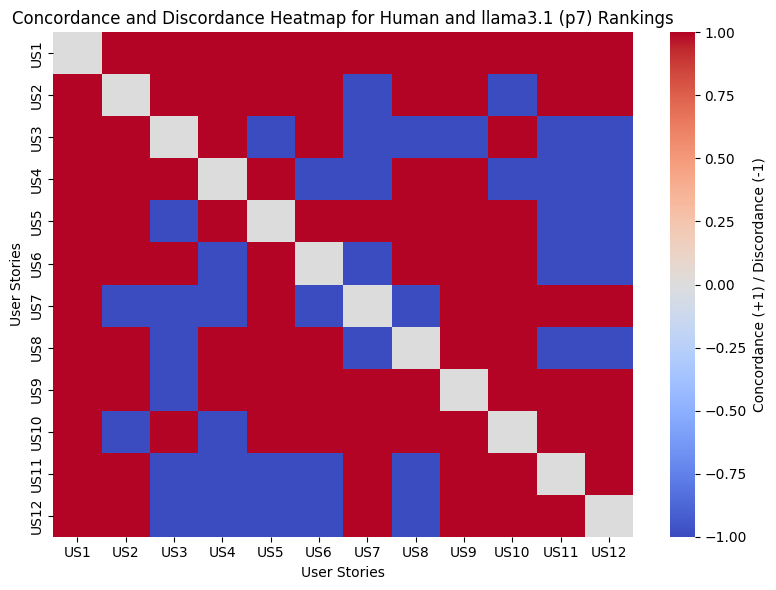

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define the rankings
# P0 (Human) from Excel
human_ranking = [1, 12, 8, 11, 5, 9, 6, 7, 2, 10, 3, 4]

# P7 from your image
p7_ranking = [1, 10, 2, 6, 4, 7, 11, 5, 3, 12, 8, 9]

# User story labels
labels = [f"US{i}" for i in range(1, 13)]

# Function to compute concordance matrix
def concordance_matrix(rank1, rank2):
    n = len(rank1)
    matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i == j:
                matrix[i, j] = 0  # self-comparison
            else:
                sign1 = np.sign(rank1[i] - rank1[j])
                sign2 = np.sign(rank2[i] - rank2[j])
                matrix[i, j] = 1 if sign1 == sign2 else -1
    return matrix

# Generate matrix
concordance = concordance_matrix(human_ranking, p7_ranking)

# Plotting
plt.figure(figsize=(8, 6))
sns.heatmap(concordance, xticklabels=labels, yticklabels=labels, cmap="coolwarm", center=0,
            cbar_kws={'label': 'Concordance (+1) / Discordance (-1)'})
plt.title("Concordance and Discordance Heatmap for Human and llama3.1 (p7) Rankings")
plt.xlabel("User Stories")
plt.ylabel("User Stories")
plt.tight_layout()
plt.show()


<ipython-input-1-2bbdd8105796>:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


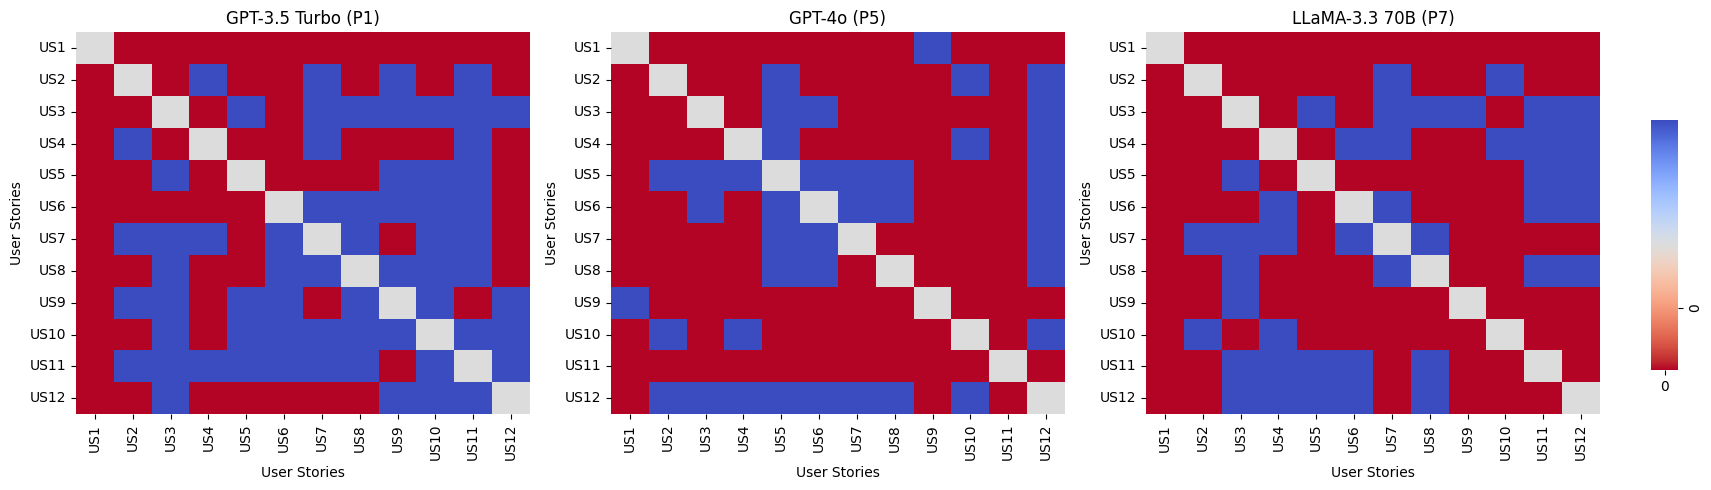

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Rankings for Human (P0), GPT-3.5 (P1), GPT-4o (P5), LLaMA 3.3–70B (P7)
human_ranking = [1, 12, 8, 11, 5, 9, 6, 7, 2, 10, 3, 4]
gpt35_ranking = [1, 7, 2, 9, 5, 6, 9, 6, 7, 2, 10, 3]
gpt4o_ranking = [2, 9, 7, 8, 10, 4, 5, 6, 1, 11, 3, 12]
llama_ranking = [1, 10, 2, 6, 4, 7, 11, 5, 3, 12, 8, 9]

# User Story labels
labels = [f"US{i}" for i in range(1, 13)]

# Concordance/discordance matrix generator
def concordance_matrix(rank1, rank2):
    n = len(rank1)
    matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i == j:
                matrix[i, j] = 0
            else:
                sign1 = np.sign(rank1[i] - rank1[j])
                sign2 = np.sign(rank2[i] - rank2[j])
                matrix[i, j] = 1 if sign1 == sign2 else -1
    return matrix

# Define model heatmaps to plot
models = [
    ("GPT-3.5 Turbo (P1)", concordance_matrix(human_ranking, gpt35_ranking)),
    ("GPT-4o (P5)", concordance_matrix(human_ranking, gpt4o_ranking)),
    ("LLaMA-3.3 70B (P7)", concordance_matrix(human_ranking, llama_ranking))
]

# Create figure
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (title, matrix) in zip(axes, models):
    sns.heatmap(matrix, ax=ax, xticklabels=labels, yticklabels=labels,
                cmap="coolwarm", center=0, vmin=-1, vmax=1, cbar=False)
    ax.set_title(title)
    ax.set_xlabel("User Stories")
    ax.set_ylabel("User Stories")

# Add shared colorbar
cbar_ax = fig.add_axes([0.92, 0.25, 0.015, 0.5])
sns.heatmap(np.array([[0, 1]]), cmap="coolwarm", center=0, cbar=True,
            cbar_ax=cbar_ax, vmin=-1, vmax=1, cbar_kws={'label': 'Concordance (+1) / Discordance (-1)'})

# Final layout and export
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.savefig("combined_heatmaps_horizontal.png", dpi=300)
plt.show()


In [ ]:
!pip install -q sentence-transformers scikit-learn pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 86.1 MB/s eta 0:00:00


In [ ]:
# 1) Install libraries


# 2) Upload your files
from google.colab import files
uploaded = files.upload()
# After you run this cell, click “Choose Files” and select:
#  - user_stories12.csv
#  - postal_worker_user_stories.csv

# 3) Import and load data
import pandas as pd
df_gpt  = pd.read_csv('user_stories12.csv')           # column: user_story
df_lla  = pd.read_csv('postal_worker_user_stories.csv')  # column: User Stories

# 4) Prepare combined Vision + MVP text
vision = """For postal workers who need an efficient and accurate way to manage deliveries, the Mobile Delivery Application is a smartphone-enabled tool that streamlines the entire delivery process from Preparation to Delivery and Accounting. Unlike traditional manual methods, the application allows users to quickly log in, scan and organize delivery items, and assign statuses in real time, all while maintaining accurate records. This reduces errors, saves time, and provides a seamless workflow, ultimately enabling postal workers to focus on delivering excellent service with improved accountability and productivity."""
mvp = """The Mobile Delivery Application is a tool that helps postal workers to prepare, deliver, and account for their deliveries. It has three main phases: Preparation, Delivery, and Accounting. In the Preparation phase, the user logs in by scanning their user barcode and adding their tour or delivery area number. The user also tags their card to the device. The user then goes to the Preparation menu and scans the items to be delivered. (…rest of MVP…)"""
combined = vision + " " + mvp

# 5) Split into sentences
import re
proj_sents = re.split(r'(?<=[.!?])\s+', combined.strip())

# 6) Compute embeddings & similarities
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Load model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Encode
emb_proj    = model.encode(proj_sents,    convert_to_tensor=True)
stories = df_gpt['user_story'].tolist() + df_lla['User Stories'].tolist()
emb_stories = model.encode(stories, convert_to_tensor=True)

# Cosine similarity matrix
sim_matrix = cosine_similarity(
    emb_stories.cpu().numpy(),
    emb_proj.cpu().numpy()
)

# Max per story → relevance
max_sims = sim_matrix.max(axis=1)

# 7) Summarize by model
labels = ['GPT4o'] * len(df_gpt) + ['Llama'] * len(df_lla)
df = pd.DataFrame({'model': labels, 'max_sim': max_sims})
summary = df.groupby('model')['max_sim'].mean().reset_index()

print("\nAverage relevance score:")
print(summary.to_string(index=False))


Saving user_stories12.csv to user_stories12.csv
Saving postal_worker_user_stories.csv to postal_worker_user_stories.csv


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


Average relevance score:
model  max_sim
GPT4o 0.429368
Llama 0.454526


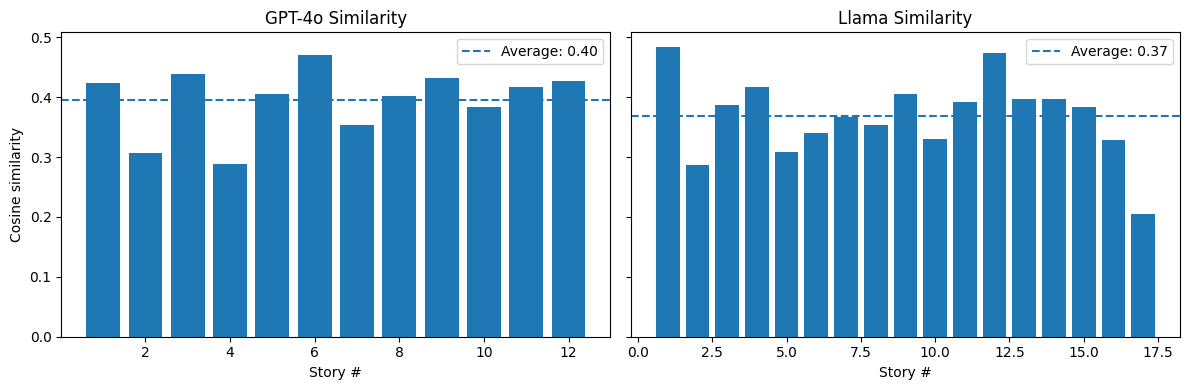

In [ ]:
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# 2. Load your CSVs (after uploading)
df_gpt = pd.read_csv('user_stories12.csv')             # col “user_story”
df_lla = pd.read_csv('postal_worker_user_stories.csv') # col “User Stories”

# 3. Combine Vision + MVP and split to sentences
vision = """For postal workers who need an efficient ... productivity."""
mvp    = """The Mobile Delivery Application ... over."""
combined = vision + " " + mvp
proj_sents = re.split(r'(?<=[.!?])\s+', combined.strip())

# 4. Prepare story lists
stories_gpt = df_gpt['user_story'].tolist()
stories_lla = df_lla['User Stories'].tolist()

# 5. Embed everything
model = SentenceTransformer('all-MiniLM-L6-v2')
emb_proj    = model.encode(proj_sents,    convert_to_tensor=True)
emb_gpt     = model.encode(stories_gpt,   convert_to_tensor=True)
emb_lla     = model.encode(stories_lla,   convert_to_tensor=True)

# 6. Compute per-story max similarity
sim_gpt = cosine_similarity(emb_gpt.cpu().numpy(), emb_proj.cpu().numpy()).max(axis=1)
sim_lla = cosine_similarity(emb_lla.cpu().numpy(), emb_proj.cpu().numpy()).max(axis=1)

# 7. Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# GPT-4o
axes[0].bar(range(1, len(sim_gpt)+1), sim_gpt)
axes[0].axhline(sim_gpt.mean(), linestyle='--', label=f"Average: {sim_gpt.mean():.2f}")
axes[0].set_title('GPT-4o Similarity')
axes[0].set_xlabel('Story #')
axes[0].set_ylabel('Cosine similarity')
axes[0].legend()

# Llama
axes[1].bar(range(1, len(sim_lla)+1), sim_lla)
axes[1].axhline(sim_lla.mean(), linestyle='--', label=f"Average: {sim_lla.mean():.2f}")
axes[1].set_title('Llama Similarity')
axes[1].set_xlabel('Story #')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
!pip install -q sentence-transformers scikit-learn pandas matplotlib

Saving user_stories12.csv to user_stories12 (2).csv
Saving postal_worker_user_stories.csv to postal_worker_user_stories (2).csv


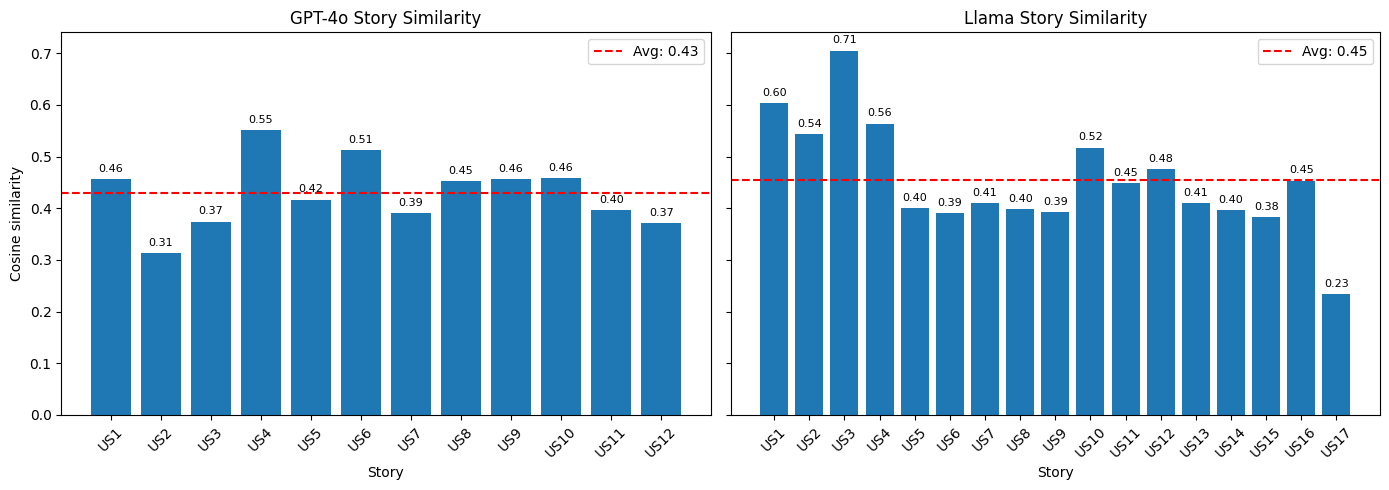

GPT-4o story similarities:
      Similarity
US1     0.456711
US2     0.312853
US3     0.374112
US4     0.551583
US5     0.416805
US6     0.512650
US7     0.390960
US8     0.452968
US9     0.456372
US10    0.458668
US11    0.397149
US12    0.371578 

Llama story similarities:
      Similarity
US1     0.604128
US2     0.542998
US3     0.705150
US4     0.563912
US5     0.400144
US6     0.390619
US7     0.410419
US8     0.398155
US9     0.392239
US10    0.517512
US11    0.448956
US12    0.476313
US13    0.409365
US14    0.396375
US15    0.382658
US16    0.453632
US17    0.234358


In [ ]:
# 1. Install required libraries

# 2. Upload your CSV files
from google.colab import files
uploaded = files.upload()
# Select:
#  - user_stories12.csv
#  - postal_worker_user_stories.csv

# 3. Imports
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# 4. Load data
df_gpt = pd.read_csv('user_stories12.csv')              # column: user_story
df_lla = pd.read_csv('postal_worker_user_stories.csv')  # column: User Stories

stories_gpt = df_gpt['user_story'].tolist()
stories_lla = df_lla['User Stories'].tolist()

# 5. Define Vision + MVP combined text
vision = """For postal workers who need an efficient and accurate way to manage deliveries, the Mobile Delivery Application is a smartphone-enabled tool that streamlines the entire delivery process from Preparation to Delivery and Accounting. Unlike traditional manual methods, the application allows users to quickly log in, scan and organize delivery items, and assign statuses in real time, all while maintaining accurate records. This reduces errors, saves time, and provides a seamless workflow, ultimately enabling postal workers to focus on delivering excellent service with improved accountability and productivity."""
mvp = """The Mobile Delivery Application is a tool that helps postal workers to prepare, deliver, and account for their deliveries. It has three main phases: Preparation, Delivery, and Accounting. In the Preparation phase, the user logs in by scanning their user barcode and adding their tour or delivery area number. The user also tags their card to the device. The user then goes to the Preparation menu and scans the items to be delivered. ... (rest of MVP)"""
combined = vision + " " + mvp

# 6. Split combined text into sentences
proj_sents = re.split(r'(?<=[.!?])\s+', combined.strip())

# 7. Load embedding model
model = SentenceTransformer('all-MiniLM-L6-v2')

# 8. Encode sentences and stories
emb_proj    = model.encode(proj_sents,    convert_to_tensor=True)
emb_gpt     = model.encode(stories_gpt,   convert_to_tensor=True)
emb_lla     = model.encode(stories_lla,   convert_to_tensor=True)

# 9. Compute max cosine similarity per story
sim_gpt = cosine_similarity(emb_gpt.cpu().numpy(), emb_proj.cpu().numpy()).max(axis=1)
sim_lla = cosine_similarity(emb_lla.cpu().numpy(), emb_proj.cpu().numpy()).max(axis=1)

# 10. Prepare labels
labels_gpt = [f'US{i}' for i in range(1, len(sim_gpt)+1)]
labels_lla = [f'US{i}' for i in range(1, len(sim_lla)+1)]

# 11. Plot side-by-side bar charts with value labels
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# GPT-4o
bars_gpt = axes[0].bar(labels_gpt, sim_gpt)
axes[0].axhline(sim_gpt.mean(), color='red', linestyle='--',
                label=f'Avg: {sim_gpt.mean():.2f}')
axes[0].set_title('GPT-4o Story Similarity')
axes[0].set_xlabel('Story')
axes[0].set_ylabel('Cosine similarity')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)
for bar in bars_gpt:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.01,
                 f'{h:.2f}', ha='center', va='bottom', fontsize=8)

# Llama (same bar color)
bars_lla = axes[1].bar(labels_lla, sim_lla, color=bars_gpt[0].get_facecolor())
axes[1].axhline(sim_lla.mean(), color='red', linestyle='--',
                label=f'Avg: {sim_lla.mean():.2f}')
axes[1].set_title('Llama Story Similarity')
axes[1].set_xlabel('Story')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)
for bar in bars_lla:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, h + 0.01,
                 f'{h:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# 12. Print per-story scores in separate tables
print("GPT-4o story similarities:")
df_gpt_scores = pd.DataFrame({'Similarity': sim_gpt}, index=labels_gpt)
print(df_gpt_scores, "\n")

print("Llama story similarities:")
df_lla_scores = pd.DataFrame({'Similarity': sim_lla}, index=labels_lla)
print(df_lla_scores)


Saving minimal_gpt35.csv to minimal_gpt35 (1).csv
Saving postal_worker_user_stories.csv to postal_worker_user_stories (4).csv
Saving user_stories12.csv to user_stories12 (4).csv


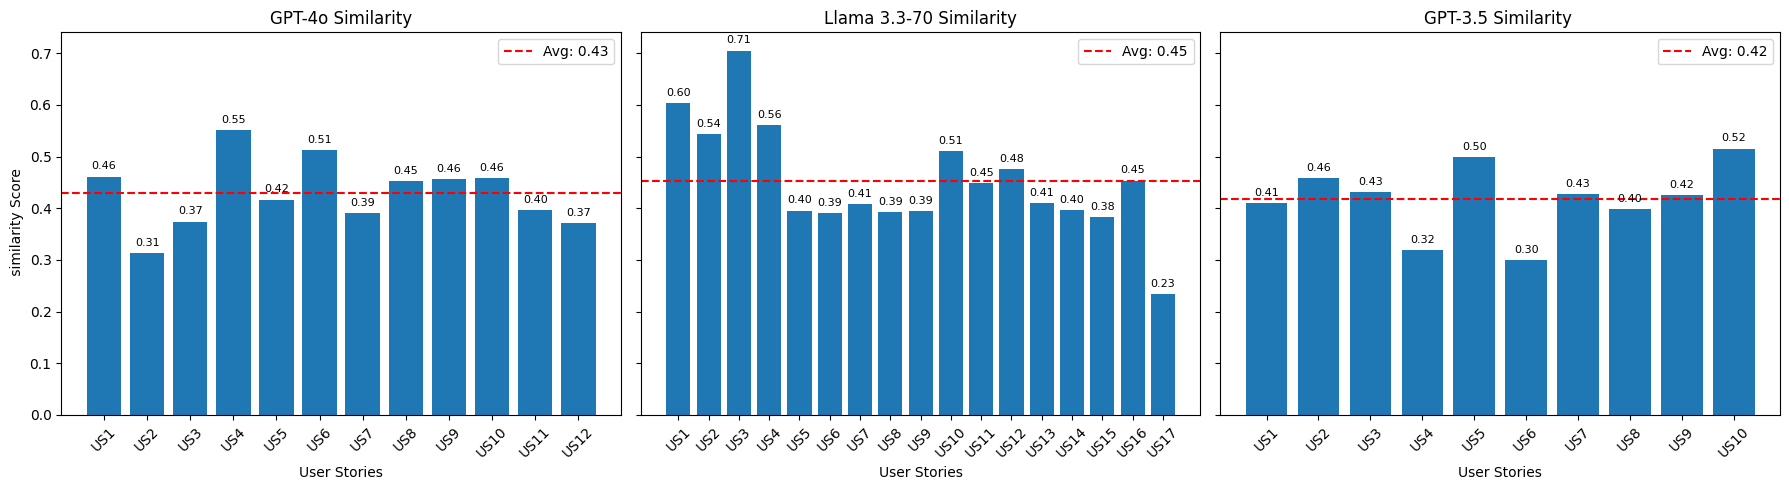

GPT-4o story similarities:
      Similarity
US1     0.461275
US2     0.312853
US3     0.374112
US4     0.551583
US5     0.416805
US6     0.512650
US7     0.390960
US8     0.452968
US9     0.456372
US10    0.458668
US11    0.397149
US12    0.371578 

Llama story similarities:
      Similarity
US1     0.604128
US2     0.542998
US3     0.705150
US4     0.561133
US5     0.395569
US6     0.390619
US7     0.408572
US8     0.391795
US9     0.394247
US10    0.510226
US11    0.448956
US12    0.476313
US13    0.409365
US14    0.396375
US15    0.382658
US16    0.453632
US17    0.234358 

GPT-3.5 story similarities:
      Similarity
US1     0.409522
US2     0.457752
US3     0.431144
US4     0.318565
US5     0.499135
US6     0.299841
US7     0.426739
US8     0.399136
US9     0.424698
US10    0.515355


In [ ]:
# 2. Upload your CSV files
from google.colab import files
uploaded = files.upload()
# Select:
#  - user_stories12.csv              # GPT-4o
#  - postal_worker_user_stories.csv  # Llama
#  - minimal_gpt35.csv               # GPT-3.5

# 3. Imports
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# 4. Load data
df_gpt4o = pd.read_csv('user_stories12.csv')              # column: user_story
df_llama = pd.read_csv('postal_worker_user_stories.csv')  # column: User Stories
df_gpt35 = pd.read_csv('minimal_gpt35.csv')               # column: user_story

stories_gpt4o = df_gpt4o['user_story'].tolist()
stories_llama = df_llama['User Stories'].tolist()
stories_gpt35 = df_gpt35['user_story'].tolist()

# 5. Define Vision + MVP combined text
vision = """For postal workers who need an efficient and accurate way to manage deliveries, the Mobile Delivery Application is a smartphone-enabled tool that streamlines the entire delivery process from Preparation to Delivery and Accounting. Unlike traditional manual methods, the application allows users to quickly log in, scan and organize delivery items, and assign statuses in real time, all while maintaining accurate records. This reduces errors, saves time, and provides a seamless workflow, ultimately enabling postal workers to focus on delivering excellent service with improved accountability and productivity."""
mvp = """The Mobile Delivery Application is a tool that helps postal workers to prepare, deliver, and account for their deliveries. It has three main phases: Preparation, Delivery, and Accounting. In the Preparation phase, the user logs in by scanning their user barcode and adding their tour or delivery area number. The user also tags their card to the device. The user then goes to the Preparation menu and scans the items to be delivered... (rest of MVP)"""
combined = vision + " " + mvp

# 6. Split combined text into sentences
proj_sents = re.split(r'(?<=[.!?])\s+', combined.strip())

# 7. Load embedding model
model = SentenceTransformer('all-MiniLM-L6-v2')

# 8. Encode sentences and stories
emb_proj      = model.encode(proj_sents,       convert_to_tensor=True)
emb_gpt4o     = model.encode(stories_gpt4o,    convert_to_tensor=True)
emb_llama     = model.encode(stories_llama,    convert_to_tensor=True)
emb_gpt35     = model.encode(stories_gpt35,    convert_to_tensor=True)

# 9. Compute max cosine similarity per story
sim_gpt4o = cosine_similarity(emb_gpt4o.cpu().numpy(), emb_proj.cpu().numpy()).max(axis=1)
sim_llama = cosine_similarity(emb_llama.cpu().numpy(), emb_proj.cpu().numpy()).max(axis=1)
sim_gpt35 = cosine_similarity(emb_gpt35.cpu().numpy(), emb_proj.cpu().numpy()).max(axis=1)

# 10. Prepare labels
labels_gpt4o = [f'US{i}' for i in range(1, len(sim_gpt4o)+1)]
labels_llama = [f'US{i}' for i in range(1, len(sim_llama)+1)]
labels_gpt35 = [f'US{i}' for i in range(1, len(sim_gpt35)+1)]

# 11. Plot side-by-side bar charts with value labels
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# GPT-4o
bars_gpt4o = axes[0].bar(labels_gpt4o, sim_gpt4o)
axes[0].axhline(sim_gpt4o.mean(), color='red', linestyle='--', label=f'Avg: {sim_gpt4o.mean():.2f}')
axes[0].set_title('GPT-4o Similarity')
axes[0].set_xlabel('User Stories')
axes[0].set_ylabel(' similarity Score')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)
for bar in bars_gpt4o:
    h = bar.get_height()
    axes[0].text(bar.get_x()+bar.get_width()/2, h+0.01, f'{h:.2f}', ha='center', va='bottom', fontsize=8)

# Llama (same color)
bars_llama = axes[1].bar(labels_llama, sim_llama, color=bars_gpt4o[0].get_facecolor())
axes[1].axhline(sim_llama.mean(), color='red', linestyle='--', label=f'Avg: {sim_llama.mean():.2f}')
axes[1].set_title('Llama 3.3-70 Similarity')
axes[1].set_xlabel('User Stories')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)
for bar in bars_llama:
    h = bar.get_height()
    axes[1].text(bar.get_x()+bar.get_width()/2, h+0.01, f'{h:.2f}', ha='center', va='bottom', fontsize=8)

# GPT-3.5
bars_gpt35 = axes[2].bar(labels_gpt35, sim_gpt35, color=bars_gpt4o[0].get_facecolor())
axes[2].axhline(sim_gpt35.mean(), color='red', linestyle='--', label=f'Avg: {sim_gpt35.mean():.2f}')
axes[2].set_title('GPT-3.5 Similarity ')
axes[2].set_xlabel('User Stories')
axes[2].legend()
axes[2].tick_params(axis='x', rotation=45)
for bar in bars_gpt35:
    h = bar.get_height()
    axes[2].text(bar.get_x()+bar.get_width()/2, h+0.01, f'{h:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# 12. Print per-story scores in separate tables
print("GPT-4o story similarities:")
print(pd.DataFrame({'Similarity': sim_gpt4o}, index=labels_gpt4o), "\n")

print("Llama story similarities:")
print(pd.DataFrame({'Similarity': sim_llama}, index=labels_llama), "\n")

print("GPT-3.5 story similarities:")
print(pd.DataFrame({'Similarity': sim_gpt35}, index=labels_gpt35))

Saving minimal_gpt35.csv to minimal_gpt35 (4).csv
Saving mistral_nemo.csv to mistral_nemo (2).csv
Saving postal_worker_user_stories.csv to postal_worker_user_stories (7).csv
Saving user_stories12.csv to user_stories12 (7).csv


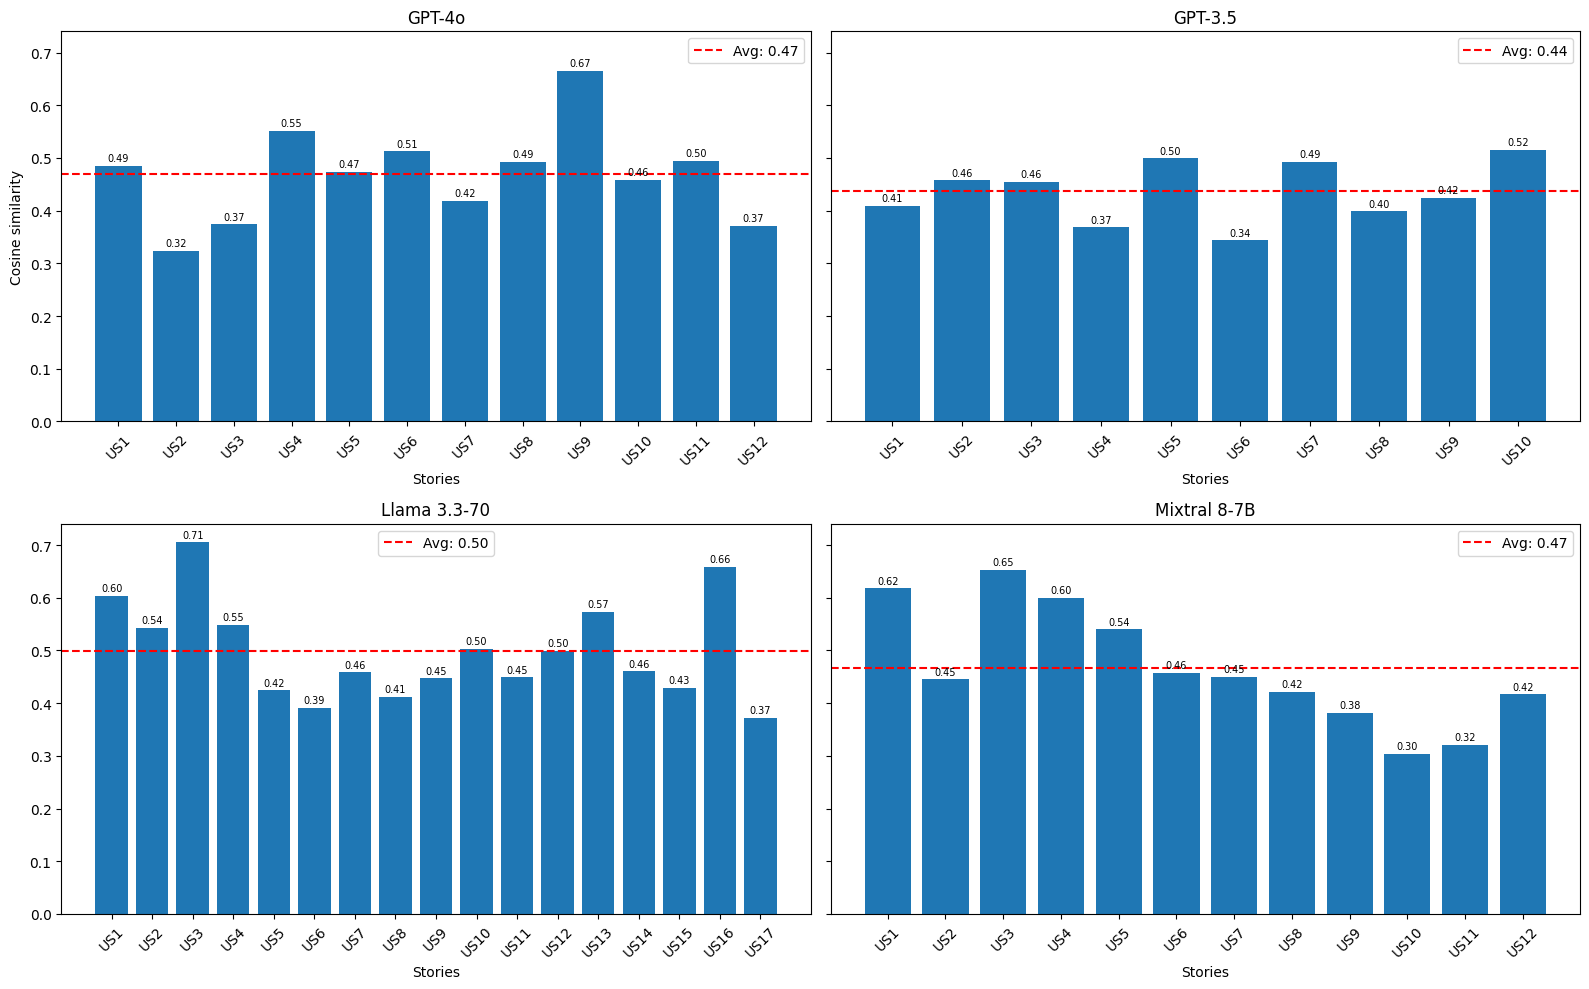

GPT-4o story similarities:
       Similarity
US1     0.485574
US2     0.324320
US3     0.374112
US4     0.551583
US5     0.474365
US6     0.512650
US7     0.419321
US8     0.492857
US9     0.665246
US10    0.458668
US11    0.495044
US12    0.371578

Llama story similarities:
       Similarity
US1     0.604128
US2     0.542998
US3     0.705150
US4     0.549171
US5     0.424611
US6     0.390619
US7     0.458804
US8     0.411634
US9     0.447419
US10    0.502595
US11    0.448956
US12    0.499482
US13    0.572930
US14    0.460133
US15    0.428585
US16    0.658742
US17    0.371804

GPT-3.5 story similarities:
       Similarity
US1     0.409522
US2     0.457577
US3     0.455161
US4     0.368265
US5     0.499135
US6     0.343702
US7     0.493293
US8     0.399136
US9     0.424698
US10    0.515355

Mixtral 8-7B story similarities:
       Similarity
US1     0.618109
US2     0.445145
US3     0.653440
US4     0.599673
US5     0.540304
US6     0.458096
US7     0.450186
US8     0.422115
US9     0.38

In [ ]:
# 2. Upload your CSV files
from google.colab import files
uploaded = files.upload()
# Choose:
#  - user_stories12.csv             (GPT-4o)
#  - postal_worker_user_stories.csv (Llama)
#  - minimal_gpt35.csv              (GPT-3.5)
#  - mistral_nemo.csv               (Mixtral 8-7B)

# 3. Imports
import pandas as pd
import re
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# 4. Load data
df_gpt4o   = pd.read_csv('user_stories12.csv')
df_llama   = pd.read_csv('postal_worker_user_stories.csv')
df_gpt35   = pd.read_csv('minimal_gpt35.csv')
df_mistral = pd.read_csv('mistral_nemo.csv')

stories_gpt4o   = df_gpt4o['user_story'].tolist()
stories_llama   = df_llama['User Stories'].tolist()
stories_gpt35   = df_gpt35['user_story'].tolist()
stories_mistral = df_mistral['user_story'].tolist()

# 5. Define combined Vision + MVP text
vision = ("For postal workers who need an efficient and accurate way to manage deliveries, "
          "the Mobile Delivery Application is a smartphone-enabled tool that streamlines "
          "the entire delivery process from Preparation to Delivery and Accounting. Unlike "
          "traditional manual methods, the application allows users to quickly log in, scan "
          "and organize delivery items, and assign statuses in real time, all while maintaining "
          "accurate records. This reduces errors, saves time, and provides a seamless workflow, "
          "ultimately enabling postal workers to focus on delivering excellent service with "
          "improved accountability and productivity.")
mvp = ("The Mobile Delivery Application is a tool that helps postal workers to prepare, deliver, "
       "and account for their deliveries. It has three main phases: Preparation, Delivery, and "
       "Accounting. In the Preparation phase, the user logs in by scanning their user barcode and "
       "adding their tour or delivery area number. The user also tags their card to the device. "
       "The user then goes to the Preparation menu and scans the items to be delivered, views "
       "item details, groups or removes items, and ends preparation. In Delivery, the user delivers "
       "and collects signatures with status options. In Accounting, the user records cash, generates "
       "barcodes, and ends their session.")
combined = vision + " " + mvp

# 6. Split into sentences
proj_sents = re.split(r'(?<=[.!?])\s+', combined.strip())

# 7. Load embedding model
model = SentenceTransformer('all-MiniLM-L6-v2')

# 8. Encode project sentences and all story sets
emb_proj      = model.encode(proj_sents,       convert_to_tensor=True)
emb_gpt4o     = model.encode(stories_gpt4o,    convert_to_tensor=True)
emb_llama     = model.encode(stories_llama,    convert_to_tensor=True)
emb_gpt35     = model.encode(stories_gpt35,    convert_to_tensor=True)
emb_mistral   = model.encode(stories_mistral,  convert_to_tensor=True)

# 9. Compute max cosine similarity per story
sim_gpt4o   = cosine_similarity(emb_gpt4o.cpu().numpy(),   emb_proj.cpu().numpy()).max(axis=1)
sim_llama   = cosine_similarity(emb_llama.cpu().numpy(),   emb_proj.cpu().numpy()).max(axis=1)
sim_gpt35   = cosine_similarity(emb_gpt35.cpu().numpy(),   emb_proj.cpu().numpy()).max(axis=1)
sim_mistral = cosine_similarity(emb_mistral.cpu().numpy(), emb_proj.cpu().numpy()).max(axis=1)

# 10. Prepare labels
labels_gpt4o   = [f'US{i}' for i in range(1, len(sim_gpt4o)+1)]
labels_llama   = [f'US{i}' for i in range(1, len(sim_llama)+1)]
labels_gpt35   = [f'US{i}' for i in range(1, len(sim_gpt35)+1)]
labels_mistral = [f'US{i}' for i in range(1, len(sim_mistral)+1)]

# 11. Plot in 2x2 layout
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=True)

# Helper to plot bars
def plot_bars(ax, labels, sims, title, color=None):
    bars = ax.bar(labels, sims, color=color)
    ax.axhline(sims.mean(), color='red', linestyle='--', label=f'Avg: {sims.mean():.2f}')
    ax.set_title(title)
    ax.set_xlabel('Stories')
    ax.legend()
    ax.tick_params(axis='x', rotation=45)
    for b in bars:
        h = b.get_height()
        ax.text(b.get_x()+b.get_width()/2, h+0.005, f'{h:.2f}', ha='center', va='bottom', fontsize=7)

# GPT-4o (top-left)
bars1 = axes[0, 0].bar(labels_gpt4o, sim_gpt4o)
default_color = bars1[0].get_facecolor()
axes[0, 0].axhline(sim_gpt4o.mean(), color='red', linestyle='--', label=f'Avg: {sim_gpt4o.mean():.2f}')
axes[0, 0].set_title('GPT-4o')
axes[0, 0].set_xlabel('Stories')
axes[0, 0].set_ylabel('Cosine similarity')
axes[0, 0].legend()
axes[0, 0].tick_params(axis='x', rotation=45)
for b in bars1:
    h = b.get_height()
    axes[0, 0].text(b.get_x()+b.get_width()/2, h+0.005, f'{h:.2f}', ha='center', va='bottom', fontsize=7)

# GPT-3.5 (top-right)
plot_bars(axes[0, 1], labels_gpt35, sim_gpt35, 'GPT-3.5', color=default_color)

# Llama (bottom-left)
plot_bars(axes[1, 0], labels_llama, sim_llama, 'Llama 3.3-70', color=default_color)

# Mixtral (bottom-right)
plot_bars(axes[1, 1], labels_mistral, sim_mistral, 'Mixtral 8-7B', color=default_color)

plt.tight_layout()
plt.show()

# 12. Print per-story scores
print("GPT-4o story similarities:\n", pd.DataFrame(sim_gpt4o, index=labels_gpt4o, columns=['Similarity']))
print("\nLlama story similarities:\n", pd.DataFrame(sim_llama, index=labels_llama, columns=['Similarity']))
print("\nGPT-3.5 story similarities:\n", pd.DataFrame(sim_gpt35, index=labels_gpt35, columns=['Similarity']))
print("\nMixtral 8-7B story similarities:\n", pd.DataFrame(sim_mistral, index=labels_mistral, columns=['Similarity']))


In [ ]:
from scipy.stats import kendalltau
import numpy as np

# Rankings for each round (US1 to US12)
p10 = [1, 6, 2, 7, 3, 9, 10, 4, 5, 12, 8, 11]
p11 = [1, 6, 2, 7, 3, 8, 9, 4, 5, 10, 11, 12]
p12 = [1, 4, 2, 5, 3, 6, 9, 7, 8, 10, 11, 12]

# Function to convert Kendall's Tau similarity to distance
def kendall_tau_distance(a, b):
    tau, _ = kendalltau(a, b)
    return 1 - tau

# Compute pairwise distances
dist_p10_p11 = kendall_tau_distance(p10, p11)
dist_p10_p12 = kendall_tau_distance(p10, p12)
dist_p11_p12 = kendall_tau_distance(p11, p12)

# Compute average distances
avg_p10 = np.mean([dist_p10_p11, dist_p10_p12])
avg_p11 = np.mean([dist_p10_p11, dist_p11_p12])
avg_p12 = np.mean([dist_p10_p12, dist_p11_p12])

# Print results
print("Kendall's Tau Distances (Mixtral):")
print(f"P10 vs P11: {dist_p10_p11:.3f}")
print(f"P10 vs P12: {dist_p10_p12:.3f}")
print(f"P11 vs P12: {dist_p11_p12:.3f}\n")

print("Average Distance per Round:")
print(f"P10: {avg_p10:.3f}")
print(f"P11: {avg_p11:.3f}")
print(f"P12: {avg_p12:.3f}\n")

# Determine closest to others
distances = {'P10': avg_p10, 'P11': avg_p11, 'P12': avg_p12}
closest = min(distances, key=distances.get)
print(f"The round most aligned with the others is: {closest}")


Kendall's Tau Distances (Mixtral):
P10 vs P11: 0.121
P10 vs P12: 0.303
P11 vs P12: 0.182

Average Distance per Round:
P10: 0.212
P11: 0.152
P12: 0.242

The round most aligned with the others is: P11


<ipython-input-2-babeb80bd2e1>:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


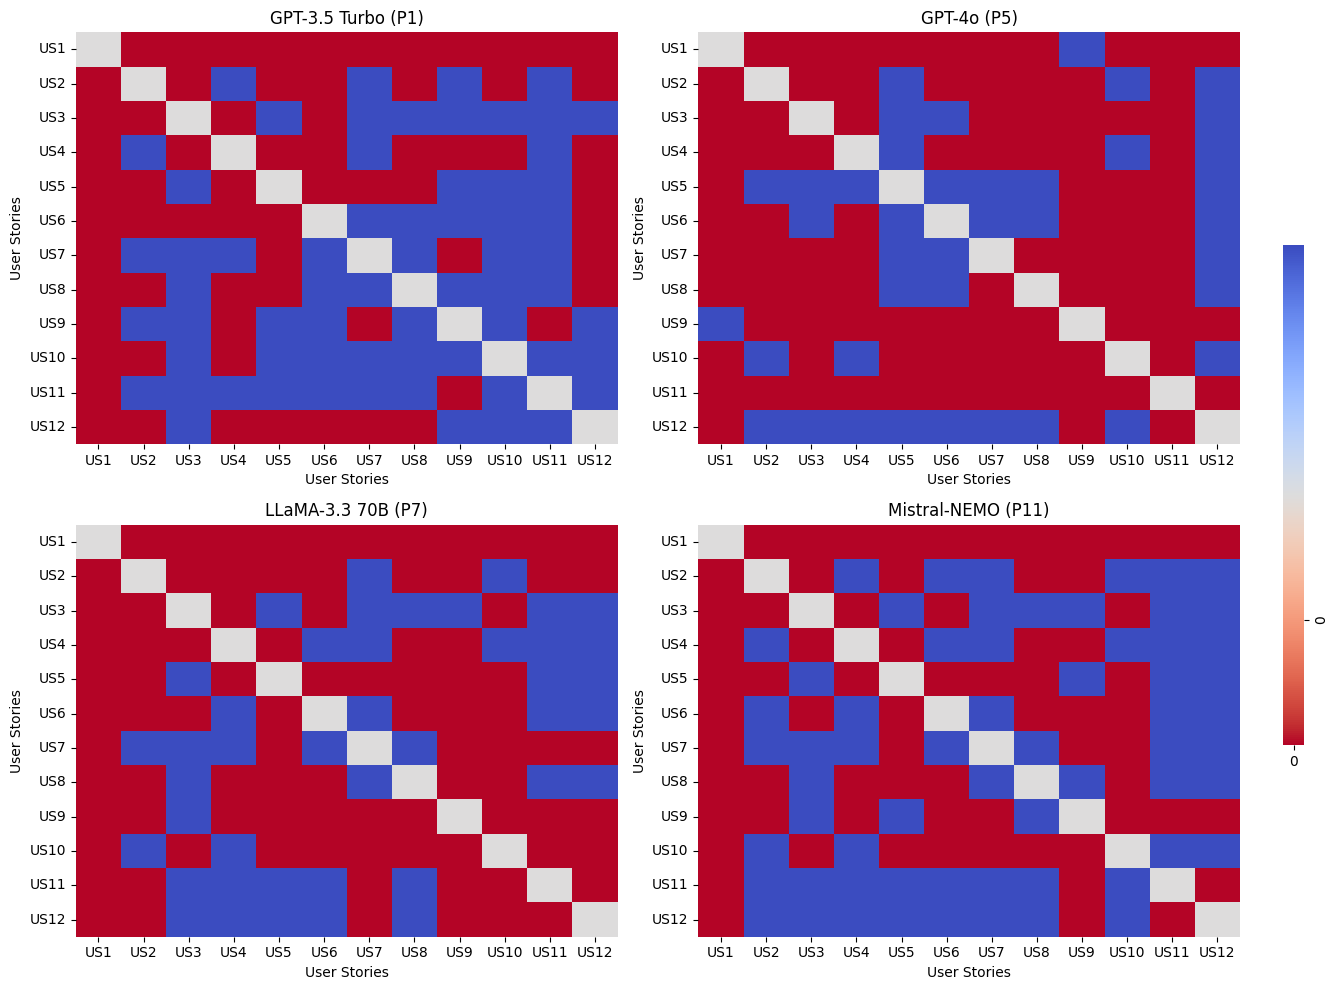

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# User Story labels
labels = [f"US{i}" for i in range(1, 13)]

# Rankings for Human and Models (P1–P11)
human_ranking   = [1, 12, 8, 11, 5, 9, 6, 7, 2, 10, 3, 4]
gpt35_ranking   = [1, 7, 2, 9, 5, 6, 9, 6, 7, 2, 10, 3]
gpt4o_ranking   = [2, 9, 7, 8, 10, 4, 5, 6, 1, 11, 3, 12]
llama_ranking   = [1, 10, 2, 6, 4, 7, 11, 5, 3, 12, 8, 9]
mistral_ranking = [1, 6, 2, 7, 3, 8, 9, 4, 5, 10, 11, 12]

# Concordance/discordance matrix generator
def concordance_matrix(rank1, rank2):
    n = len(rank1)
    matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i == j:
                matrix[i, j] = 0
            else:
                sign1 = np.sign(rank1[i] - rank1[j])
                sign2 = np.sign(rank2[i] - rank2[j])
                matrix[i, j] = 1 if sign1 == sign2 else -1
    return matrix

# Define heatmaps to plot
models = [
    ("GPT-3.5 Turbo (P1)",  concordance_matrix(human_ranking, gpt35_ranking)),
    ("GPT-4o (P5)",         concordance_matrix(human_ranking, gpt4o_ranking)),
    ("LLaMA-3.3 70B (P7)",  concordance_matrix(human_ranking, llama_ranking)),
    ("Mistral-NEMO (P11)",  concordance_matrix(human_ranking, mistral_ranking))
]

# Create 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot each model's matrix
for ax, (title, matrix) in zip(axes.flat, models):
    sns.heatmap(matrix, ax=ax, xticklabels=labels, yticklabels=labels,
                cmap="coolwarm", center=0, vmin=-1, vmax=1, cbar=False)
    ax.set_title(title)
    ax.set_xlabel("User Stories")
    ax.set_ylabel("User Stories")

# Shared colorbar
cbar_ax = fig.add_axes([0.92, 0.25, 0.015, 0.5])
sns.heatmap(np.array([[0, 1]]), cmap="coolwarm", center=0, cbar=True,
            cbar_ax=cbar_ax, vmin=-1, vmax=1,
            cbar_kws={'label': 'Concordance (+1) / Discordance (-1)'})

# Layout
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.savefig("concordance_heatmaps_2x2.png", dpi=300)
plt.show()
